## Dataset Overview

This dataset contains`16,411` records of crop-related data, focusing on key environmental conditions and their effect on crop growth stages. The dataset includes information such as soil type, seedling stage, moisture index (MOI), temperature, and humidity. Each row represents a unique crop sample with its corresponding environmental factors and an output result, which can be used for machine learning models to predict crop health or irrigation requirementseal-time data.

Features:

* **crop ID** : Unique identifier for the crop (categorical)
* **soil_type** : Type of soil for the crop (e.g., Black Soil, Red Soil)
* **Seedling Stage** : The growth stage of the crop (e.g., Germination)
* **MOI(Moisture Index)** : The soil moisture content at the time of data collection (integer)
* **temp(Temperature)** : The ambient temperature in degrees Celsius (integer)
* **humidity** : The relative humidity in percentage (float)
* **result** : Indicates whether the crop requires irrigation or not (binary: 1 = yes, 0 = no)

Potential Use Cases

* **Irrigation management**: This dataset can be used to train models that predict the need for irrigation based on environmental conditio
* **Agriculture research**: Researchers can use this dataset to study the influence of soil and climate conditions on crop growth stag
* **Smart farming applications**: Can be integrated into IoT systems for automating irrigation decisions based on real-time daa.

## Importing Required Libraries 

In [1]:
## Manipulation Packages
import numpy as np
import pandas as pd

# Visualization Packages
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

## Model Building Packages
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

print('All packages have been loaded successfully!!!')

All packages have been loaded successfully!!!


## Loading The Data and Dataset Overview

In [2]:
### Loading the data
df = pd.read_csv('cropdata_updated.csv')
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [3]:
## Checking for the number of rows and columns
print(f'Our data has {df.shape[0]} rows and {df.shape[1]} columns')

Our data has 16411 rows and 7 columns


In [4]:
## Checking for duplicates
print('='*80)
print(f'We have {df.duplicated().sum()} duplicate values in our dataset')
print('='*80)
print('Further preprocessing or cleaning for duplicated values should be considered')

We have 128 duplicate values in our dataset
Further preprocessing or cleaning for duplicated values should be considered


In [5]:
## Checking for null values
print('='*80)
print('There were no missing values found in our dataset')
print('='*80)
df.isna().sum()

There were no missing values found in our dataset


crop ID           0
soil_type         0
Seedling Stage    0
MOI               0
temp              0
humidity          0
result            0
dtype: int64

In [6]:
## Checking DataTypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [7]:
## Dropping Duplicates
df.drop_duplicates(keep='first',inplace=True)

In [8]:
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [9]:
df.shape

(16283, 7)

In [10]:
## Renaming Columns
df.rename(columns={'crop ID':'crop_name',
                   'Seedling Stage':'seedling_stage',
                  'MOI':'moi'},inplace=True)
df.columns

Index(['crop_name', 'soil_type', 'seedling_stage', 'moi', 'temp', 'humidity',
       'result'],
      dtype='object')

## EDA and Visualization

In [11]:
#3 Summary Satistics
df.describe()

,moi,temp,humidity,result
count,16283.000000,16283.000000,16283.000000,16283.000000
mean,43.781858,28.912547,63.316004,0.520236
std,27.198158,9.692754,22.634381,0.622436
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,21.000000,44.000000,0.000000
50%,41.000000,29.000000,69.000000,0.000000
75%,64.000000,37.000000,83.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [12]:
df.temp.unique()

array([25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
       42, 43, 44, 45, 46, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13],
      dtype=int64)

Text(0.5, 0, 'Temperature')

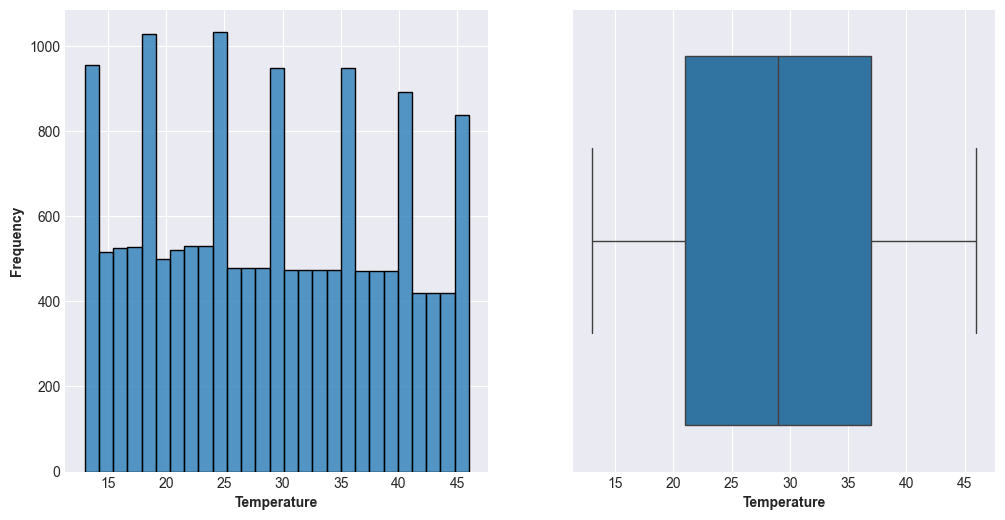

In [13]:
## Dstribution of the numerical columns
## Temperature
style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(data=df,x='temp');
plt.xlabel('Temperature',fontweight='bold')
plt.ylabel('Frequency',fontweight='bold')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='temp');
plt.xlabel('Temperature',fontweight='bold')

Text(0.5, 0, 'Humidity')

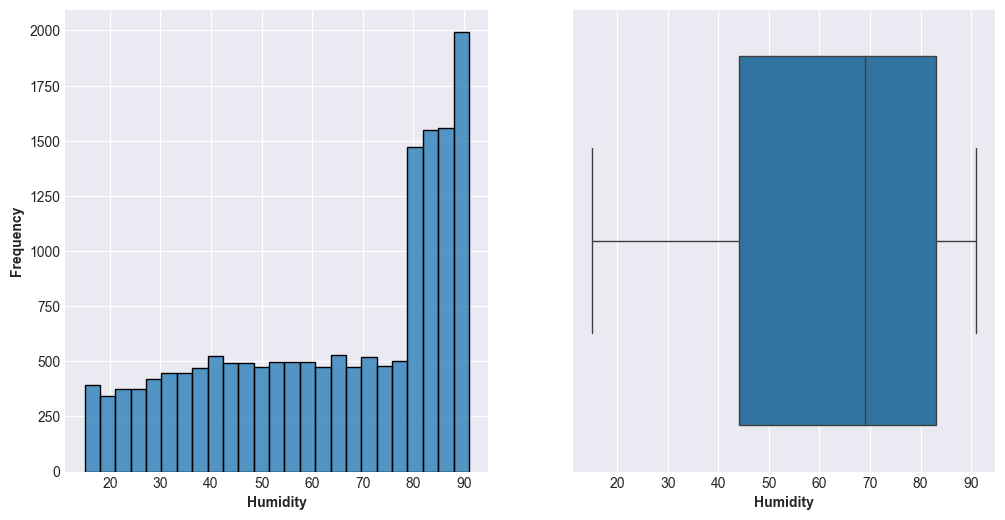

In [14]:
## Humidity
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(data=df,x='humidity');
plt.xlabel('Humidity',fontweight='bold')
plt.ylabel('Frequency',fontweight='bold')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='humidity');
plt.xlabel('Humidity',fontweight='bold')

Text(0.5, 0, 'MOI')

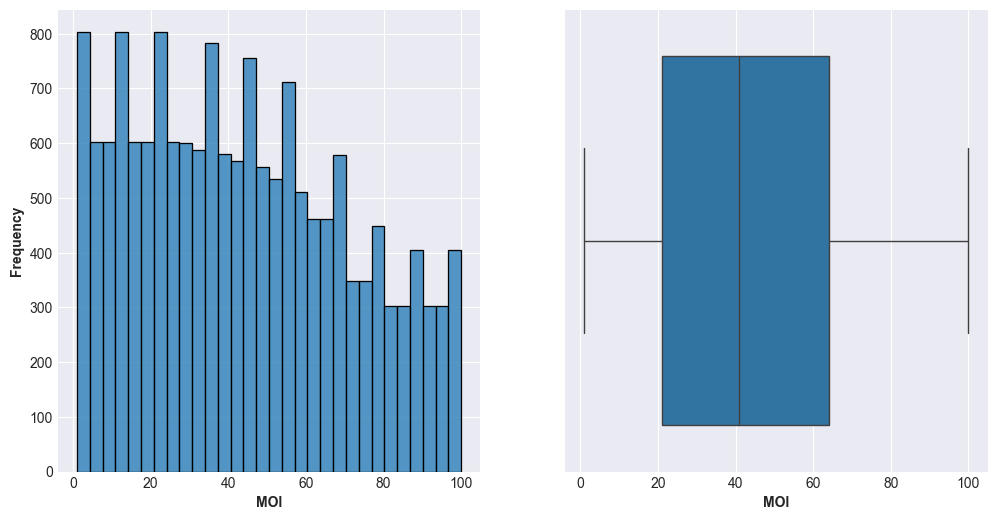

In [15]:
## MOI
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(data=df,x='moi');
plt.xlabel('MOI',fontweight='bold')
plt.ylabel('Frequency',fontweight='bold')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='moi');
plt.xlabel('MOI',fontweight='bold')

<Axes: xlabel='result', ylabel='count'>

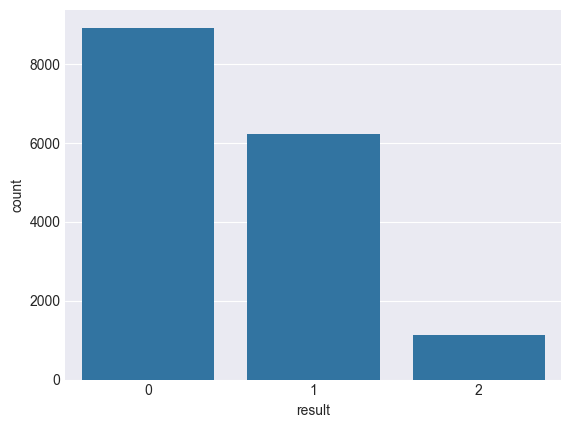

In [16]:
## Viusualize the target variable
sns.countplot(data=df,x='result')

In [17]:
df_result_2 = df[df['result']==2]
df_result_2.head()

,crop_name,soil_type,seedling_stage,moi,temp,humidity,result
30,Wheat,Black Soil,Germination,31,33,60.0,2
31,Wheat,Black Soil,Germination,32,34,57.5,2
32,Wheat,Black Soil,Germination,33,35,55.0,2
33,Wheat,Black Soil,Germination,34,36,52.5,2
34,Wheat,Black Soil,Germination,35,37,50.0,2


In [18]:
print(df_result_2['crop_name'].unique())
print(df_result_2.soil_type.unique())
print(df_result_2.seedling_stage.unique())
print(df_result_2.moi.describe())
print(df_result_2.temp.describe())
print(df_result_2.humidity.describe())

['Wheat' 'Potato' 'Carrot' 'Tomato' 'Chilli']
['Black Soil' 'Alluvial Soil' 'Sandy Soil' 'Red Soil' 'Clay Soil'
 'Loam Soil' 'Chalky Soil']
['Germination' 'Seedling Stage'
 'Vegetative Growth / Root or Tuber Development' 'Flowering' 'Pollination'
 'Fruit/Grain/Bulb Formation' 'Maturation' 'Harvest']
count    1122.000000
mean       67.633690
std        13.255617
min        30.000000
25%        61.000000
50%        70.000000
75%        77.000000
max        90.000000
Name: moi, dtype: float64
count    1122.000000
mean       35.407308
std         6.252269
min        25.000000
25%        30.000000
50%        35.000000
75%        41.000000
max        46.000000
Name: temp, dtype: float64
count    1122.000000
mean       49.366399
std        18.326076
min        15.000000
25%        34.100000
50%        50.000000
75%        65.000000
max        80.000000
Name: humidity, dtype: float64


In [19]:
df_result_2.shape

(1122, 7)

In [20]:
df_result_2['humidity'].value_counts(normalize=True)

humidity
53.0    0.040998
35.0    0.037433
80.0    0.036542
74.0    0.034759
50.0    0.034759
          ...   
67.5    0.000891
69.2    0.000891
72.5    0.000891
66.5    0.000891
61.1    0.000891
Name: proportion, Length: 89, dtype: float64

In [22]:
df_result_2['temp'].value_counts(normalize=True)

temp
40    0.058824
34    0.056150
42    0.054367
28    0.049911
32    0.049911
26    0.049020
44    0.047237
36    0.047237
27    0.046346
35    0.045455
38    0.045455
25    0.044563
30    0.044563
33    0.044563
41    0.043672
39    0.041889
37    0.041889
43    0.040998
46    0.038324
29    0.037433
31    0.036542
45    0.035651
Name: proportion, dtype: float64

In [27]:
df_result_2.humidity.value_counts().head(20).values.sum()/df_result_2.humidity.value_counts().values.sum()

0.6452762923351159

In [23]:
df_result_2['temp'].nunique()

22

In [24]:
df_result_2['humidity'].nunique()

89

In [30]:
df_result_2.temp.value_counts().head(15).values.sum()/df_result_2.temp.value_counts().values.sum()

0.7272727272727273

## Preprocessing and Feature Engineering

In [18]:
df.result.value_counts()

result
0    8934
1    6227
2    1122
Name: count, dtype: int64

In [19]:
## Fixing the target variable
df_copy = df.copy()
df_copy['result'] = df_copy['result'].apply(lambda x : 0 if x == 2 else x)
df_copy['result'].value_counts()

result
0    10056
1     6227
Name: count, dtype: int64

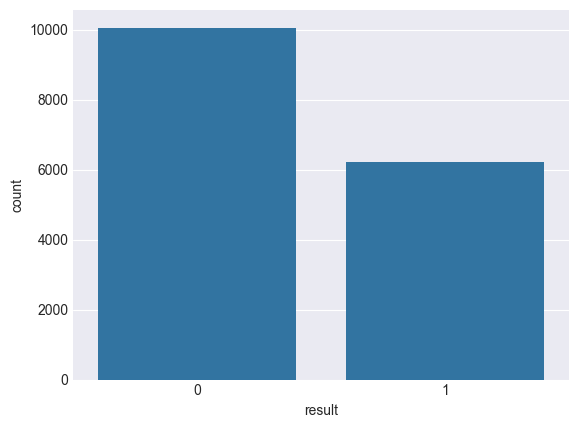

In [20]:
sns.countplot(x=df_copy['result']);

In [21]:
df['crop_name'].unique()

array(['Wheat', 'Potato', 'Carrot', 'Tomato', 'Chilli'], dtype=object)

In [22]:
df['soil_type'].unique()

array(['Black Soil', 'Alluvial Soil', 'Sandy Soil', 'Red Soil',
       'Clay Soil', 'Loam Soil', 'Chalky Soil'], dtype=object)

In [23]:
df['seedling_stage'].unique()

array(['Germination', 'Seedling Stage',
       'Vegetative Growth / Root or Tuber Development', 'Flowering',
       'Pollination', 'Fruit/Grain/Bulb Formation', 'Maturation',
       'Harvest'], dtype=object)

In [24]:
encoded_df = pd.get_dummies(data=df_copy,drop_first=True,
                            columns=['crop_name','soil_type','seedling_stage'],dtype=int)
encoded_df.head()

,moi,temp,humidity,result,crop_name_Chilli,crop_name_Potato,crop_name_Tomato,crop_name_Wheat,soil_type_Black Soil,soil_type_Chalky Soil,...,soil_type_Loam Soil,soil_type_Red Soil,soil_type_Sandy Soil,seedling_stage_Fruit/Grain/Bulb Formation,seedling_stage_Germination,seedling_stage_Harvest,seedling_stage_Maturation,seedling_stage_Pollination,seedling_stage_Seedling Stage,seedling_stage_Vegetative Growth / Root or Tuber Development
0,1,25,80.0,1,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
1,2,26,77.0,1,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
2,3,27,74.0,1,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
3,4,28,71.0,1,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
4,5,29,68.0,1,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0


## Model Building

In [25]:
## Data spliting
X = encoded_df.drop('result',axis='columns')
y = encoded_df['result']

In [26]:
## Splitting into Train and Test
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

### Building Our Baseline Models

In [27]:
## Logistic Regression
lr = LogisticRegression()
lr.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
## Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [29]:
## Knn
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [30]:
## RandomForest
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [31]:
## GradientBoosting
gdb = GradientBoostingClassifier()
gdb.fit(X_train,y_train)

GradientBoostingClassifier()

In [36]:
## A simple check on Logistic
def baseline_model_training(model_name,model):
    model_train_accuracy= model.score(X_train,y_train)
    model_test_accuracy = model.score(X_test,y_test)
    print(f'Accuracy on train for {model_name} is: {model_train_accuracy:.4f}, Accuracy on test for {model_name} is: {model_test_accuracy:.4f}')
    # return model_train_accuracy, model_test_accuracy

Accuracy on train for Linear Regression is: 0.8442, Accuracy on test for Linear Regression is: 0.8456


In [39]:
## A simple check on Decision Tree
baseline_model_training('Linear Regression',lr)
baseline_model_training('Decision Tree',dt)
baseline_model_training('Gradient Boosting',gdb)
baseline_model_training('KNN',knn)

Accuracy on train for Linear Regression is: 0.8442, Accuracy on test for Linear Regression is: 0.8456
Accuracy on train for Decision Tree is: 1.0000, Accuracy on test for Decision Tree is: 0.9988
Accuracy on train for Gradient Boosting is: 0.9759, Accuracy on test for Gradient Boosting is: 0.9748
Accuracy on train for SVM is: 0.9162, Accuracy on test for SVM is: 0.9263
Accuracy on train for KNN is: 0.9469, Accuracy on test for KNN is: 0.9340


### HyperParameter Tuning

In [40]:
## Hyperparameter Tuning For Logistic Regression
lr_params = {'C': [0.1, 0.01, 0.001],
            'max_iter': [50, 70]}
lr_rand = RandomizedSearchCV(
    estimator=lr,
    param_distributions= lr_params,
    cv=5,
    n_jobs= -1
)

In [41]:
lr_rand.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': [0.1, 0.01, 0.001],
                                        'max_iter': [50, 70]})

In [42]:
print(f'Best estimator:{lr_rand.best_estimator_},\nBest parameters {lr_rand.best_params_}, \nBest Acurracy {lr_rand.best_score_}')

Best estimator:LogisticRegression(C=0.001, max_iter=70),
Best parameters {'max_iter': 70, 'C': 0.001}, 
Best Acurracy 0.8575163471863985


In [43]:
## Hyperparameter Tuning For Decision Tree
dt_params = { 'max_depth': [5, 10, 20],
            'min_samples_split': [2, 5, 10]}
dt_rand = RandomizedSearchCV(
    estimator=dt,
    param_distributions= dt_params,
    cv=5,
    n_jobs= -1
)

In [45]:
dt_rand.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20],
                                        'min_samples_split': [2, 5, 10]})

In [52]:
print('Best Estimators and Parameters on GridSearch and Randomized Search')
print('='*80)
print(f'Best estimator:{dt_rand.best_estimator_},\nBest parameters {dt_rand.best_params_}, \nBest Acurracy {dt_rand.best_score_}')
print('='*80)
# print(f'Best estimator:{dt_rand.best_estimator_},\nBest parameters {dt_rand.best_params_}, \nBest Acurracy {dt_rand.best_score_}')

Best Estimators and Parameters on GridSearch and Randomized Search
Best estimator:DecisionTreeClassifier(max_depth=20, min_samples_split=5),
Best parameters {'min_samples_split': 5, 'max_depth': 20}, 
Best Acurracy 0.9972361139140004


In [53]:
## Hyperparameter Tuning For KNN
knn_params = {'n_neighbors': [5, 10, 15],
            'metric': ['euclidean']}
knn_rand = RandomizedSearchCV(
    estimator=knn,
    param_distributions= knn_params,
    cv=5,
    n_jobs= -1
)

In [55]:
knn_rand.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
                   param_distributions={'metric': ['euclidean'],
                                        'n_neighbors': [5, 10, 15]})

In [57]:
print('Best Estimators and Parameters on GridSearch and Randomized Search')
print('='*80)
print(f'Best estimator:{knn_rand.best_estimator_}\nBest parameters {knn_rand.best_params_}\nBest Acurracy {knn_rand.best_score_}')
print('='*80)
# print(f'Best estimator:{knn_rand.best_estimator_},\nBest parameters {knn_rand.best_params_}, \nBest Acurracy {knn_rand.best_score_}')

Best Estimators and Parameters on GridSearch and Randomized Search
Best estimator:KNeighborsClassifier(metric='euclidean', n_neighbors=10)
Best parameters {'n_neighbors': 10, 'metric': 'euclidean'}
Best Acurracy 0.9266853842380568


In [58]:
## Hyperparameter Tuning For RandomForest 
rf_params = {'n_estimators': [50, 100, 150],
            'max_depth': [5, 10, 20]}

rf_rand = RandomizedSearchCV(
    estimator=rf,
    param_distributions= rf_params,
    cv=5,
    n_jobs= -1
)

In [59]:
rf_rand.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20],
                                        'n_estimators': [50, 100, 150]})

In [62]:
print('Best Estimators and Parameters on GridSearch and Randomized Search')
print('='*80)
print(f'Best estimator:{rf_rand.best_estimator_}\nBest parameters {rf_rand.best_params_}\nBest Acurracy {rf_rand.best_score_}')
print('='*80)
# print(f'Best estimator:{rf_rand.best_estimator_},\nBest parameters {rf_rand.best_params_}, \nBest Acurracy {rf_rand.best_score_}')

Best Estimators and Parameters on GridSearch and Randomized Search
Best estimator:RandomForestClassifier(max_depth=20, n_estimators=150)
Best parameters {'n_estimators': 150, 'max_depth': 20}
Best Acurracy 0.9962382984490242


In [63]:
## Hyperparameter Tuning For Gradient Boosting
gdb_params = {'n_estimators': [50, 100, 150], 
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10]}


gdb_rand = RandomizedSearchCV(
    estimator=gdb,
    param_distributions= gdb_params,
    cv=5,
    n_jobs= -1
)

In [64]:
gdb_rand.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]})

In [65]:
print(' Best Estimators and Parameters on GridSearch and Randomized Search')
print('='*80)
print(f'Best estimator:{gdb_rand.best_estimator_},\nBest parameters {gdb_rand.best_params_}, \nBest Acurracy {gdb_rand.best_score_}')
print('='*80)
# print(f'Best estimator:{gdb_rand.best_estimator_},\nBest parameters {gdb_rand.best_params_}, \nBest Acurracy {gdb_rand.best_score_}')

 Best Estimators and Parameters on GridSearch and Randomized Search
Best estimator:GradientBoostingClassifier(max_depth=10, min_samples_split=5),
Best parameters {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}, 
Best Acurracy 0.9983110288821162


### Best Model

In [75]:
lr_rand.best_params_

{'max_iter': 70, 'C': 0.001}

In [77]:
## Final Model for Logistics Regression
final_lr =LogisticRegression(max_iter= 70,C= 0.001)
final_lr.fit(X_train,y_train)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.001, max_iter=70)

In [76]:
knn_rand.best_params_

{'n_neighbors': 10, 'metric': 'euclidean'}

In [78]:
## Final Model for KNN
final_knn = KNeighborsClassifier(metric='euclidean',n_neighbors=10)
final_knn.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [81]:
rf_rand.best_params_

{'n_estimators': 150, 'max_depth': 20}

In [82]:
## Final Model for RandomForest
final_rf = RandomForestClassifier(max_depth= 20, n_estimators= 150)
final_rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, n_estimators=150)

In [84]:
dt_rand.best_params_

{'min_samples_split': 5, 'max_depth': 20}

In [85]:
## Final Model for Decision Tree
final_dt = DecisionTreeClassifier(max_depth = 20,min_samples_split = 5)
final_dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=20, min_samples_split=5)

In [151]:
gdb_rand.best_params_

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}

In [152]:
## Final Model for Gradient Boosting
final_gdb = GradientBoostingClassifier(max_depth= 10, min_samples_split = 5, n_estimators = 100)
final_gdb.fit(X_train,y_train)

GradientBoostingClassifier(max_depth=10, min_samples_split=5)

## Evaluation 

In [153]:
## Predicting with Logitics Regression Model
final_ypred_lr = final_lr.predict(X_test)
lr_confusion = confusion_matrix(y_test,final_ypred_lr)

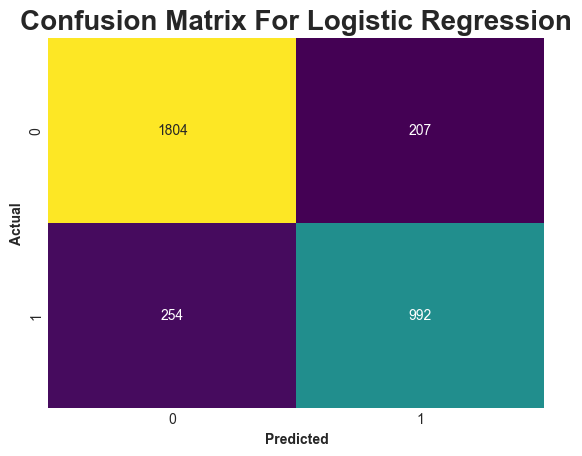

In [155]:
## Confusion Matrix For Logistic Regression
def confusion_matrix_plot(confusion_matrix,title):
    sns.heatmap(lr_confusion,annot=True,
                cmap='viridis',fmt='d',cbar=False)
    plt.title(title,fontweight='bold',fontsize=20)
    plt.xlabel('Predicted',fontweight='bold')
    plt.ylabel('Actual',fontweight='bold');
    
confusion_matrix_plot(lr_confusion,'Confusion Matrix For Logistic Regression')

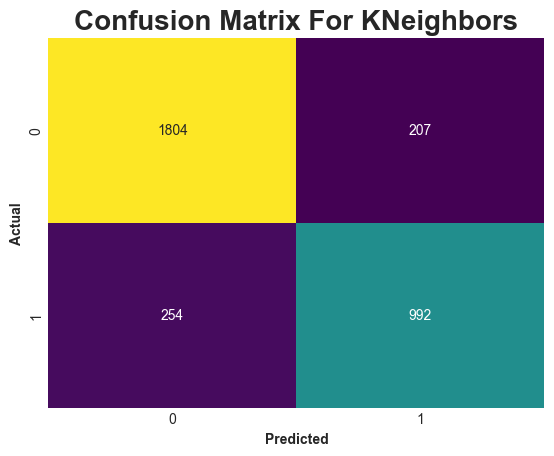

In [156]:
## Predicting with KNN Model
final_ypred_knn = final_knn.predict(X_test)
knn_confusion = confusion_matrix(y_test,final_ypred_knn)
## Confusion Matrix For Logistic Regression
confusion_matrix_plot(knn_confusion,'Confusion Matrix For KNeighbors')

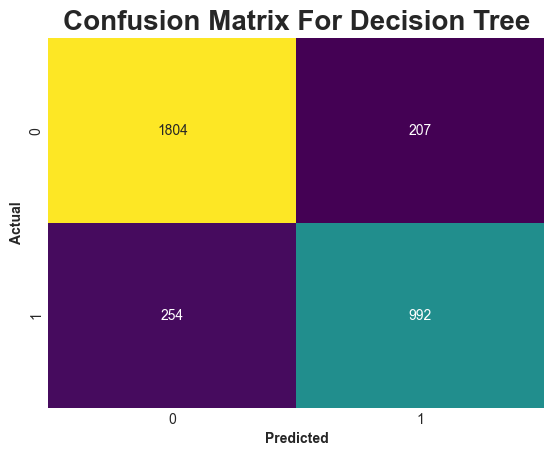

In [158]:
## Predicting with Decision Tree Model
final_ypred_dt = final_dt.predict(X_test)
dt_confusion = confusion_matrix(y_test,final_ypred_dt)
## Confusion Matrix For Logistic Regression
confusion_matrix_plot(dt_confusion,'Confusion Matrix For Decision Tree')

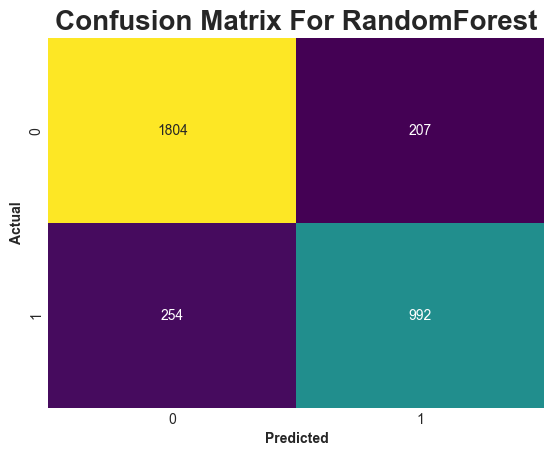

In [159]:
## Predicting with RandomForest Model
final_ypred_rf = final_rf.predict(X_test)
rf_confusion = confusion_matrix(y_test,final_ypred_rf)
## Confusion Matrix For Logistic Regression
confusion_matrix_plot(rf_confusion,'Confusion Matrix For RandomForest')

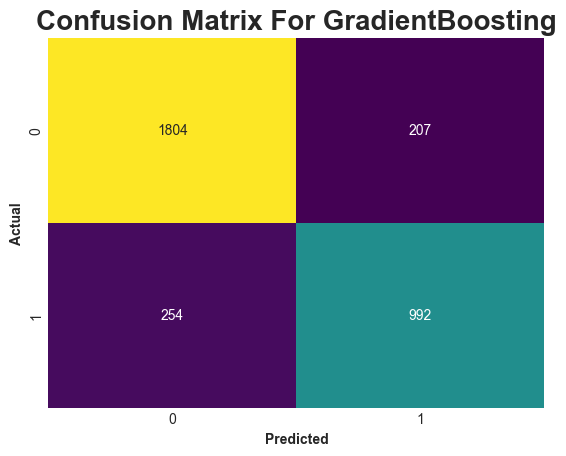

In [160]:
## Predicting with GradientBoosting Model
final_ypred_gdb = final_gdb.predict(X_test)
gdb_confusion = confusion_matrix(y_test,final_ypred_gdb)
## Confusion Matrix For Logistic Regression
confusion_matrix_plot(gdb_confusion,'Confusion Matrix For GradientBoosting')

In [161]:
lr_auc = roc_auc_score(final_ypred_lr,y_test)
knn_auc = roc_auc_score(final_ypred_knn,y_test)
dt_auc = roc_auc_score(final_ypred_dt,y_test)
rf_auc = roc_auc_score(final_ypred_rf,y_test)
gdb_auc = roc_auc_score(final_ypred_gdb,y_test)
# roc_auc_score(final_ypred_,y_test)
lr_auc,knn_auc,dt_auc,rf_auc,gdb_auc

(0.8519676666091195,
 0.9345164825900009,
 0.9498949867049205,
 0.9975003907508476,
 0.996851066510579,
 0.9974003334788678)

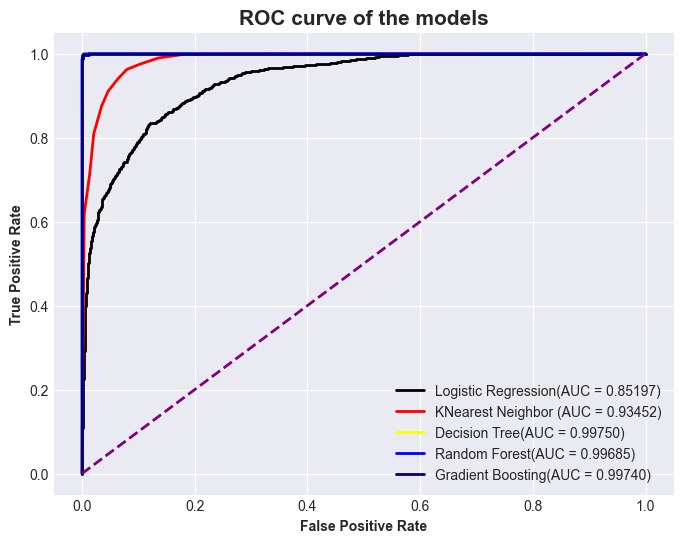

In [162]:
lr_prob = final_lr.predict_proba(X_test)[:, 1]
knn_prob = final_knn.predict_proba(X_test)[:, 1]
dt_prob = final_dt.predict_proba(X_test)[:, 1]
rf_prob = final_rf.predict_proba(X_test)[:, 1]
gdb_prob = final_gdb.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_prob, pos_label=1)
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_test, knn_prob, pos_label=1)
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_prob, pos_label=1)
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob, pos_label=1)
gdb_fpr, gdb_tpr, gdb_thresholds = roc_curve(y_test, gdb_prob, pos_label=1)


plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, color='black', lw=2, label=f'Logistic Regression(AUC = {lr_auc:.5f})')
plt.plot(knn_fpr, knn_tpr, color='red', lw=2, label=f'KNearest Neighbor (AUC = {knn_auc:.5f})')
plt.plot(dt_fpr, dt_tpr, color='yellow', lw=2, label=f'Decision Tree(AUC = {dt_auc:.5f})')
plt.plot(rf_fpr, rf_tpr, color='blue', lw=2, label=f'Random Forest(AUC = {rf_auc:.5f})')
plt.plot(gdb_fpr, gdb_tpr, color='navy', lw=2, label=f'Gradient Boosting(AUC = {gdb_auc:.5f})')
plt.plot([0, 1], [0, 1], color='purple', lw=2, linestyle='--')
plt.xlabel('False Positive Rate',fontweight='bold')
plt.ylabel('True Positive Rate',fontweight='bold')
plt.title('ROC curve of the models',
          fontsize=15,
          fontweight='bold')
plt.legend(loc="lower right")
plt.show()

In [163]:
## Building a pipeline
pipe = Pipeline([('ohe',OneHotEncoder(drop='first')),
    ('gdb',GradientBoostingClassifier(n_estimators=100, min_samples_split=5, max_depth=10))
])

In [167]:
pipe.fit(X_train,y_train).score(X_train,y_train)

0.9633809304467987

In [168]:
pipe.score(X_test,y_test)

0.959778937672705

1.0

In [169]:
from sklearn.preprocessing import StandardScaler

In [ ]:
StandardScaler()